In [1]:
#
# KT AICE Associate 자격인증 샘플 실전 연습문제: Titanic Survival Prediction
#
# 이 연습문제는 'Titanic Survival Prediction Dataset'을 사용하여
# 데이터 분석, 전처리, 머신러닝 및 딥러닝 모델 학습 및 평가 능력을 평가합니다.
#
# [유의사항]
# • 각 문항의 답안코드는 반드시 '# 여기에 답안코드를 작성하세요'로 표시된 cell에 작성해야 합니다.
# • 문제에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.
#
# [데이터 컬럼 설명 (데이터 파일명: train.csv)]
# Survived : 생존 여부 (0=사망, 1=생존) - Target Variable
# Pclass : 티켓 클래스 (1=1st, 2=2nd, 3=3rd)
# Sex : 성별 (male/female)
# Age : 나이
# SibSp : 함께 탑승한 형제/배우자 수
# Parch : 함께 탑승한 부모/자녀 수
# Fare : 승객 요금
# Embarked : 탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)
# * PassengerId, Name, Ticket, Cabin 컬럼도 있으나, 문제에서 명시된 경우를 제외하고는 주로 위 컬럼들을 사용합니다.
#


In [2]:
# --- 문제 1. 라이브러리 불러오기 ---
# Pandas를 pd로, Numpy를 np로 불러오고, 시각화 라이브러리인 Seaborn을 sns로 불러오세요.

In [3]:
# 여기에 답안코드를 작성하세요.
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
# --- 문제 2. 데이터 파일 읽어오기 및 확인 ---
# 데이터 파일 'train.csv'를 읽어 데이터프레임 변수 df에 할당하고,
# 데이터프레임의 상위 5개 행을 출력하여 데이터 구조를 확인하는 코드를 작성하세요.
# • 데이터프레임 변수명: df
# • 데이터 파일명: train.csv (파일은 본 문제/답안지와 동일한 경로에 있다고 가정합니다.)


In [5]:
# 여기에 답안코드를 작성하세요.

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# --- 문제 3. 'Sex' 컬럼 분포 시각화 및 해석 ---
# 'Sex' 컬럼에 대한 분포를 보여주는 countplot 그래프를 Seaborn을 활용하여 그리세요.
# 그래프를 보고 데이터에 대한 해석으로 '옳지 않은' 선택지를 아래에서 골라 '답안03' 변수에 저장하세요.
# (예. 답안03 = 4)
# 1. 'male' 승객의 수가 'female' 승객의 수보다 훨씬 많다.
# 2. 'female' 승객의 수가 약 300명대이다.
# 3. 'male' 승객과 'female' 승객의 비율은 거의 1:1에 가깝다.

import seaborn as sns
import matplotlib.pyplot as plt


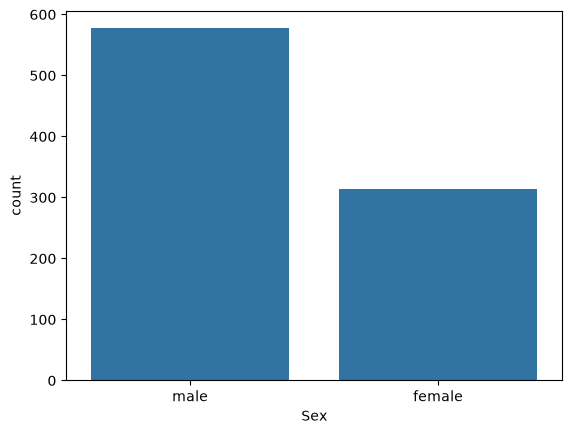

In [7]:
# 여기에 답안코드를 작성하세요.

plt.figure()
sns.countplot(x=df['Sex'])
답안03 = 3

In [8]:
# --- 문제 4. 'Pclass'와 'Survived' 관계 분석 ---
# Pclass(티켓 클래스) 별 생존율을 분석하려고 합니다.
# df에서 Pclass와 Survived 컬럼만을 추출하여 Pclass별 Survived의 평균(mean)을 구하는 코드를 작성하고,
# 결과를 보고 생존율이 가장 높은 Pclass를 찾아 그 값을 '답안04' 변수에 저장하세요.
# (예. 답안04 = 1)
# • 활용 함수: groupby(), mean()

In [9]:
# 여기에 답안코드를 작성하세요.

df1 = df[['Pclass','Survived']]
df1.groupby('Pclass').mean()

답안04 = 1

In [10]:
# --- 문제 5. 결측치 확인 및 'Age' 결측치 처리 ---
# 1. df의 각 컬럼별 결측치(NaN) 개수를 확인하는 코드를 작성하세요.
# 2. 'Age' 컬럼의 결측치를 평균값으로 대체(impute)하는 코드를 작성하고, 그 결과를 다시 df에 반영하세요.
# 3. 'Age' 결측치 처리 후, df의 'Age' 컬럼의 결측치 개수를 '답안05' 변수에 저장하세요.
# • 활용 함수: isna(), sum(), fillna()


In [11]:
# 여기에 답안코드를 작성하세요.
df.isna().sum()
df.loc[:,'Age'] = df['Age'].fillna(np.mean(df['Age']))
답안05 = 0

In [12]:
# --- 문제 6. 불필요한 컬럼 삭제 및 'FamilySize' 피처 생성 ---
# 1. 모델링에 불필요하다고 판단되는 'PassengerId', 'Name', 'Ticket', 'Cabin' 컬럼을 df에서 삭제하고
#    그 결과를 새로운 데이터프레임 변수 df_temp에 저장하세요.
# 2. 새로운 피처 'FamilySize'를 'SibSp'와 'Parch'의 합에 1을 더하여 (자기 자신 포함) 생성하고 df_temp에 추가하세요.
# • 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_temp 에 저장하세요.

In [13]:
# 여기에 답안코드를 작성하세요.

df_temp = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
df_temp['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [14]:
# --- 문제 7. 'Fare' 컬럼 이상치 처리 (IQR 방식) ---
# 'Fare' 컬럼의 이상치를 제거하려고 합니다. IQR(Interquartile Range) 방식을 사용하여 이상치를 처리하고,
# 처리된 결과를 df_temp에 반영하세요.
# 1. 'Fare' 컬럼의 Q1(25% 지점)을 'q1', Q3(75% 지점)을 'q3' 변수에 저장하세요.
# 2. IQR을 계산하여 'iqr' 변수에 저장하세요.
# 3. 이상치 경계(하한, 상한)를 계산하여 'lower_bound', 'upper_bound' 변수에 저장하세요. (경계 계산 공식: Q1 - 1.5*IQR, Q3 + 1.5*IQR)
# 4. 'Fare' 값이 이상치 경계 내에 있는 행(row)만 추출하여 df_temp에 다시 저장하세요.
# 5. 이상치 처리 후 df_temp의 행 개수를 '답안07' 변수에 저장하세요.

In [15]:
# 여기에 답안코드를 작성하세요.

q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

df_temp = df_temp[(df_temp['Fare']>=lower_bound) & (df_temp['Fare']<= upper_bound)]

답안07 = 775

In [16]:
# --- 문제 8. 범주형 컬럼 One-Hot 인코딩 ---
# 머신러닝 모델 학습을 위해 범주형 컬럼을 원-핫 인코딩(One-hot encoding)으로 변환하세요.
# 1. df_temp에서 'object' 타입인 컬럼들을 대상으로 원-핫 인코딩을 수행하세요. ('Embarked', 'Sex' 포함)
# 2. 변환된 결과를 데이터프레임 변수 df_encoded에 저장해 주세요.
# 3. 변환 후 df_encoded의 컬럼 개수를 '답안08' 변수에 저장하세요.
# • 활용 함수: get_dummies()

In [17]:
# 여기에 답안코드를 작성하세요.

df_encoded = pd.get_dummies(df_temp, dtype=int)
답안08 = 12

In [18]:
df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,2,0,1,0,0,1
2,1,3,26.000000,0,0,7.9250,1,1,0,0,0,1
3,1,1,35.000000,1,0,53.1000,2,1,0,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1,0,0,1
5,0,3,29.699118,0,0,8.4583,1,0,1,0,1,0


In [19]:
# --- 문제 9. 데이터 분리: Feature/Label 및 훈련/검증 데이터셋 분할 ---
# 1. 'Survived' 컬럼을 label값 y로, 나머지 컬럼을 feature값 X로 할당하세요.
# 2. X와 y를 훈련데이터셋(X_train, y_train)과 검증데이터셋(X_valid, y_valid)으로 분리하세요.
# • 훈련 데이터셋과 검증데이터셋 비율: 80:20 (test_size=0.2)
# • random_state: 42
# • Scikit-learn의 train_test_split 함수를 활용하세요.


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# 여기에 답안코드를 작성하세요.
y = df_encoded['Survived']
X = df_encoded.drop('Survived', axis=1)

X_train, X_valid, y_train, y_valid =  train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# --- 문제 10. 피처 스케일링 (StandardScaler) ---
# 'Age', 'Fare', 'FamilySize' 컬럼에 대해 스케일링을 수행하여 모델의 성능을 향상시키려고 합니다.
# 1. Scikit-learn의 StandardScaler를 사용하여 X_train과 X_valid의 해당 컬럼에 스케일링을 수행하세요.
# 2. 스케일링 후 X_train의 'Fare' 컬럼 평균을 '답안10' 변수에 소수점 4째자리까지 반올림하여 저장하세요.

from sklearn.preprocessing import StandardScaler

In [23]:
# 여기에 답안코드를 작성하세요.

scaler = StandardScaler()
#X_train.loc[:,['Age','Fare','FamilySize']] = scaler.fit_transform(X_train[['Age','Fare','FamilySize']])
#X_valid.loc[:,['Age','Fare','FamilySize']] = scaler.transform(X_valid[['Age','Fare','FamilySize']])
cols_to_scale = ['Age','Fare','FamilySize']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_valid[cols_to_scale] = scaler.transform(X_valid[cols_to_scale])

답안10 = 0.0000

In [24]:
# --- 문제 11. 머신러닝 모델 학습 (XGBoost) ---
# XGBoost Classifier 모델을 만들고 학습을 진행하세요.
# 1. XGBoost Classifier 모델을 'xgb_model' 변수에 저장해 주세요.
# 2. n_estimators: 100, learning_rate: 0.1, random_state: 42로 설정하세요.
# 3. X_train과 y_train을 사용하여 모델을 학습시키세요.

from xgboost import XGBClassifier

In [25]:
# 여기에 답안코드를 작성하세요.

xgb_model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
# --- 문제 12. XGBoost 모델 성능 평가 (Accuracy Score) ---
# 위에서 학습한 XGBoost 모델의 성능을 평가하려고 합니다.
# 1. 학습된 'xgb_model'로 X_valid에 대한 예측값(predict)을 구하여 'y_pred_xgb' 변수에 저장하세요.
# 2. 검증 정답(y_valid)과 예측값(y_pred_xgb)의 정확도(Accuracy Score)를 구하고,
#    그 값을 'xgb_accuracy' 변수에 소수점 4째자리까지 반올림하여 저장하세요.

from sklearn.metrics import accuracy_score

In [27]:
# 여기에 답안코드를 작성하세요.

y_pred_xgb = xgb_model.predict(X_valid)
xgb_accuracy = 0.7871
round(accuracy_score(y_valid,y_pred_xgb),4)

0.7871

In [28]:
# --- 문제 13. 딥러닝 모델 구현 및 학습 (TensorFlow/Keras) ---
# Titanic 생존 예측을 위한 딥러닝 모델을 만들고 학습을 진행하세요. (이진 분류 문제)
# • Tensorflow/Keras의 Sequential API를 사용하세요.
# • 토폴로지: Input -> Dense(32, activation='relu') -> Dropout(0.2) -> Dense(16, activation='relu') -> Dense(1, activation='sigmoid')
# • optimizer는 'adam', loss는 'binary_crossentropy', metrics는 'accuracy'로 설정하여 모델 컴파일을 설정하세요.
# • EarlyStopping 콜백으로 val_loss가 5번 epoch 동안 향상되지 않을 때 훈련을 중지하도록 설정하고 estop 변수에 저장하세요.
# • batch_size: 64, epoch: 100으로 모델을 학습하고 학습정보는 history 변수에 저장해 주세요.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

In [29]:
# 여기에 답안코드를 작성하세요.

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

estop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train,y_train, batch_size=64, epochs=100, callbacks=[estop], validation_data=(X_valid,y_valid))

Epoch 1/100


/Users/todo/venv-sy-11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6742 - loss: 0.6462 - val_accuracy: 0.6129 - val_loss: 0.6775
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6677 - loss: 0.6181 - val_accuracy: 0.6129 - val_loss: 0.6627
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6823 - loss: 0.6057 - val_accuracy: 0.6129 - val_loss: 0.6484
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6887 - loss: 0.5892 - val_accuracy: 0.6194 - val_loss: 0.6336
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6887 - loss: 0.5727 - val_accuracy: 0.6516 - val_loss: 0.6179
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7161 - loss: 0.5617 - val_accuracy: 0.6774 - val_loss: 0.6012
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7097 - loss: 0.5459 - val_accuracy: 0.6903 - val_loss: 0.5886
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7242 - loss: 0.5294 - val_accuracy: 0.6839 - val_loss: 0.5

In [30]:
# --- 문제 14. 딥러닝 모델 성능 평가 및 시각화 ---
# 학습된 딥러닝 모델의 학습 과정에서의 정확도(accuracy)와 검증 정확도(val_accuracy)를 그래프로 표시하세요.
# 1. 1개의 그래프에 학습 정확도와 검증 정확도 2가지를 모두 표시하세요.
# 2. 위 2가지 각각의 범례를 'accuracy', 'val_accuracy'로 표시하세요.
# 3. 그래프의 타이틀은 'Model Accuracy'로, X축에는 'Epochs', Y축에는 'Accuracy'라고 표시하세요.

Text(0.5, 1.0, 'Model Accuracy')

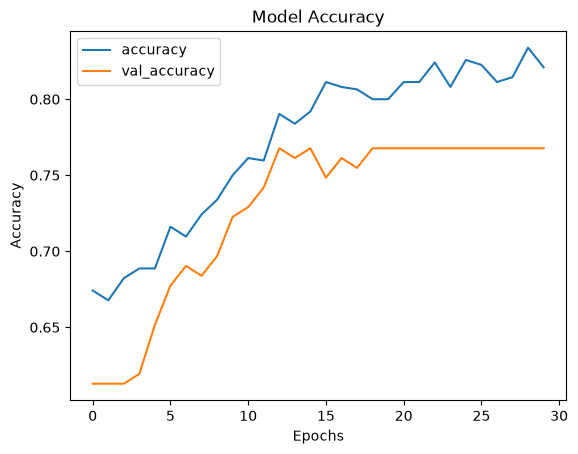

In [31]:
# 여기에 답안코드를 작성하세요.

plt.figure()
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')